In [1]:
import os
from pathlib import Path
from typing import Optional
from itertools import chain

import fastmri
import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch
from data_utils import *
from datasets import *
from fastmri.data.transforms import tensor_to_complex_np
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
from torch.utils.data import DataLoader, TensorDataset

from model import *
from torch.optim import SGD, Adam, AdamW
from train_utils import *

import plotly.graph_objects as go

In [2]:
path_to_data = '/itet-stor/mcrespo/bmicdatasets-originals/Originals/fastMRI/brain/multicoil_train/'
n_volumes = 2
n_slices = 2
with_mask = False  # NOTE: During inference phase, set to True.
acceleration = 4
center_frac= 0.15
vol_id0= 0

In [4]:
vol = 0
name_file = '/itet-stor/mcrespo/bmicdatasets-originals/Originals/fastMRI/brain/multicoil_train/file_brain_AXT1POST_203_6000861.h5'
path_to_data = Path(name_file)

dataset = KCoordDataset(path_to_data, n_volumes=n_volumes, n_slices=2, with_mask=False, acceleration=4, center_frac=0.15)
center = dataset.metadata[vol]["center"]
left_idx, right_idx, center_vals = center["left_idx"], center["right_idx"], center["vals"]
shape = dataset.metadata[vol]["shape"]
n_slices, n_coils, height, width = shape

# Create tensors of indices for each dimension
kx_ids = torch.cat([torch.arange(left_idx), torch.arange(right_idx, width)])
ky_ids = torch.arange(height)
kz_ids = torch.arange(n_slices)
coil_ids = torch.arange(n_coils)

# Use meshgrid to create expanded grids
kspace_ids = torch.meshgrid(kx_ids, ky_ids, kz_ids, coil_ids, indexing="ij")
kspace_ids = torch.stack(kspace_ids, dim=-1).reshape(-1, len(kspace_ids))

path_to_data = Path(path_to_data)
kspace_gt = []
ground_truth = []
if path_to_data.is_dir():
    files = sorted(
        [
            file
            for file in path_to_data.iterdir()
            if file.suffix == ".h5" and "AXT1POST_205" in file.name            
        ]
    )[:n_volumes]
    
for file in files:
    with h5py.File(file, "r") as hf:
        kspace_gt.append(to_tensor(preprocess_kspace(hf["kspace"][()]))[:n_slices])
        ground_truth.append(hf["reconstruction_rss"][()][: n_slices])


NameError: name 'files' is not defined

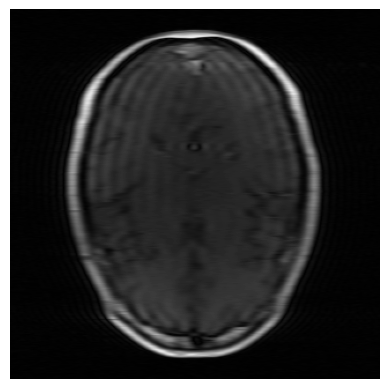

In [82]:
## VOLUME
vol_id = 4
left_idx, right_idx = dataset.metadata[vol_id]["center"]["left_idx"], dataset.metadata[vol_id]["center"]["right_idx"]
vol_kspace = torch.tensor(tensor_to_complex_np(kspace_gt[vol_id]))
vol_img = ground_truth[vol_id]

inverse_prediction = vol_kspace
prediction = torch.zeros_like(vol_kspace)

prediction[..., left_idx:right_idx] = vol_kspace[..., left_idx:right_idx]
inverse_prediction[..., left_idx:right_idx] = 0

pred_img = np.abs(rss(inverse_fft2_shift((prediction))))
real_img = np.abs(rss(inverse_fft2_shift((vol_kspace))))
pred_edges = np.abs(rss(inverse_fft2_shift((inverse_prediction))))

plt.figure()
plt.imshow(pred_img[0], cmap='gray')
plt.axis('off')
plt.show()


#### PRINT BASELINE METRICS #####
val_psnr = psnr(vol_img, pred_img)
val_ssim = ssim(vol_img, pred_img)
val_nmse = nmse(vol_img, pred_img)

print(f'Baseline metrics: {val_psnr}, {val_ssim}, {val_nmse}')

In [ ]:
vol = 0
gt = tensor_to_complex_np(kspace_gt[vol])

mask = np.load('/scratch_net/ken/mcrespo/proj_marina/logs/multivol_12_11_test/mask.npy')
cste_mod = np.load('/scratch_net/ken/mcrespo/proj_marina/logs/multivol_12_11_test/cste.npy')

####### mask
y_kspace_data_u = gt  * (mask)
y_kspace_prediction_u = kspace_gt[4] * (1-mask)
y_kspace_final = y_kspace_data_u + y_kspace_prediction_u

y_kspace_data_rss = rss(y_kspace_data_u)
y_kspace_prediction_rss = rss(y_kspace_prediction_u)
y_kspace_final_rss = rss(y_kspace_final)

y_kspace_final[..., left_idx:right_idx] = center_vals
y_img_final = np.abs(rss(inverse_fft2_shift(y_kspace_final)))

###### predict the edges - image
y_img_edges = np.abs(rss(inverse_fft2_shift(volume_kspace)))


###### predict the center - image
volume_kspace[..., left_idx:right_idx] = center_vals
y_img_edges_center = np.abs(rss(inverse_fft2_shift(volume_kspace)))

cste_arg = np.pi/180
# ###### raw img w/o 
# y_kspace_data[..., left_idx:right_idx] = 0
# raw_img_edges = np.abs(rss(inverse_fft2_shift(y_kspace_data)))

# cste_mod = dataset.metadata[vol]["norm_cste"]

fig = plt.figure(figsize=(10,10))
# for slice_id in range(shape[0]):


plt.subplot(1,3,1)
plt.imshow(np.abs(y_kspace_data_rss[0])/cste_mod)
plt.axis('off')
plt.title('M·ydata')
plt.subplot(1,3,2)
plt.imshow(np.abs(y_kspace_prediction_rss[0])/cste_mod)
plt.axis('off')
plt.title('(1-M)·ypred')
plt.subplot(1,3,3)                
plt.imshow(np.abs(y_kspace_final_rss[0])/cste_mod)
plt.axis('off')
plt.title('M·ydata + (1-M)·ypred')
    
# self.writer.add_figure(
#     f"prediction/vol_{vol_id}/slice_{slice_id}/kspace_composed",
#     fig,
#     global_step=epoch_idx,
# )
# plt.close(fig)


fig = plt.figure(figsize=(10,10))

plt.subplot(1,3,1)
plt.imshow(y_img_edges[0], cmap='gray')
plt.axis('off')
plt.title('Predicted edges')
plt.subplot(1,3,2)
plt.imshow(y_img_edges_center[0], cmap='gray')
plt.axis('off')
plt.title('Predicted edges + center')
plt.subplot(1,3,3)                
plt.imshow(y_img_final[0], cmap='gray')
plt.axis('off')
plt.title('Predicted + Acquired')
    
# self.writer.add_figure(
#     f"prediction/vol_{vol_id}/slice_{slice_id}/volume img",
#     fig,
#     global_step=epoch_idx,
# )
# plt.close(fig)
# volume_kspace_unweighted[..., left_idx:right_idx] = 0
volume_kspace[...,left_idx:right_idx] = center_vals
modulus = np.abs(rss(volume_kspace))
phase = np.angle(rss(volume_kspace))
fig = plt.figure(figsize=(10,10))
# for slice_id in range(shape[0]):
plt.subplot(1,2,1)
eps = 1.e-45
plt.imshow(modulus[0]/cste_mod)
plt.axis('off')
plt.colorbar()
plt.title('Acquired kspace')
plt.subplot(1,2,2)
plt.imshow(phase[0]/cste_arg)
plt.axis('off')
plt.title('Acquired img')
    

GRADIENT WRT EMBEDDING VOLUME & EMBEDDING OF COIL 

In [141]:
embedding = copy.deepcopy(embeddings_coil)
for vect in embedding.parameters():
    tshape = torch.tensor(vect.size(), dtype = float)
    scale = torch.norm(tshape)
    noise = torch.normal(0, torch.std(vect).item()/scale, size=vect.size())
    vect.data.add_(noise)


np.mean(torch.norm((embedding.weight.data - embeddings_coil.weight.data).detach().cpu()))

TypeError: mean() received an invalid combination of arguments - got (dtype=NoneType, out=NoneType, axis=NoneType, ), but expected one of:
 * (*, torch.dtype dtype = None)
 * (tuple of ints dim, bool keepdim = False, *, torch.dtype dtype = None)
 * (tuple of names dim, bool keepdim = False, *, torch.dtype dtype = None)


In [2]:
import copy
vol_dim = 1024
coil_dim = 512
checkpoint_1024 = '/scratch_net/ken/mcrespo/proj_marina/logs_new/multivol_02_06_train/2025-02-06_15h59m38s/checkpoints/epoch_0499.pt'
state_dict = torch.load(checkpoint_1024,  map_location=torch.device('cpu'))['model_state_dict']
model = Siren(coord_dim=3, vol_embedding_dim=vol_dim, coil_embedding_dim=coil_dim, hidden_dim=512, n_layers=8, out_dim=2, L=10)
model.load_state_dict(state_dict)
model_temp = copy.deepcopy(model)

# for _, tensor in model_temp.named_parameters():
#     tshape = torch.tensor(tensor.shape, dtype=float)
#     scale = torch.norm(tshape)/10

#     noise = torch.normal(0, torch.std(tensor).item()/scale, tensor.size())
#     tensor.data.add_(noise)

# for (layer1, tensor1), (layer2, tensor2) in zip(model.named_parameters(), model_temp.named_parameters()):
#     # print(tensor1.shape)
#     print(f'{layer1}, {layer2}')
#     print(torch.norm(tensor1.data-tensor2.data))

/tmp/ipykernel_14448/1227516714.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_1024,  map_location=torch.device('cpu'))['model_state_

In [7]:
for name, tensor in model.named_parameters():
    print(tensor)

Parameter containing:
tensor([[ 3.1800e-04,  1.4954e-04, -2.6408e-04,  ..., -3.8207e-05,
         -6.7102e-04, -3.0346e-04],
        [-6.4640e-04,  4.9923e-04, -5.7175e-04,  ...,  1.9731e-03,
          8.8675e-04,  9.0412e-04],
        [ 2.3434e-04,  2.7082e-05,  5.4468e-04,  ..., -3.4215e-05,
         -1.1352e-04, -6.9576e-04],
        ...,
        [-2.2206e-04, -1.6881e-04,  2.6546e-04,  ..., -6.6430e-04,
         -5.0174e-04,  7.0562e-06],
        [ 2.8336e-04,  6.0158e-04, -5.9771e-04,  ...,  1.0304e-03,
          5.6000e-04,  1.2954e-03],
        [ 6.1512e-04,  3.0164e-04,  2.2603e-05,  ..., -3.9238e-04,
          1.1754e-04, -1.8731e-04]], requires_grad=True)
Parameter containing:
tensor([ 1.9300e-02,  3.5021e-03, -1.9913e-02,  1.9868e-02,  2.4736e-03,
         1.9134e-02,  2.4401e-02,  1.2348e-02,  1.5242e-02,  6.2874e-03,
         4.5283e-03,  2.4935e-02, -7.3641e-03, -6.9166e-04, -2.1638e-02,
         5.4722e-04, -4.7698e-03,  1.6934e-02, -6.4926e-03, -5.5225e-03,
         5.1

In [8]:
0.001/0.1

0.01

In [4]:
coil_dim = 512
vol_dim = 1024
# coil_dim = 128
# vol_dim = 256

# coil_dim = 256
# vol_dim = 512
#####################################################################
# volume embedding
#####################################################################
embeddings_vol = torch.nn.Embedding(
    len(dataset.metadata), vol_dim
)

## Coil embeddings initialization
########################################################
coil_sizes = []
for i in range(len(dataset.metadata)):
    _, n_coils, _, _ = dataset.metadata[i]["shape"]
    coil_sizes.append(n_coils)
    
total_n_coils = torch.cumsum(torch.tensor(coil_sizes), dim=0)[-1]

# Create the indexes to access the embedding coil table
start_idx = torch.tensor([0] + list(torch.cumsum(torch.tensor(coil_sizes), dim=0)[:-1]))
embeddings_coil = torch.nn.Embedding(total_n_coils.item(), coil_dim)


### DEFINE THE MODELS AND LOAD THE STATE DICT
model = Siren(coord_dim=3, vol_embedding_dim=vol_dim, coil_embedding_dim=coil_dim, hidden_dim=512, n_layers=8, out_dim=2, L=10)


# checkpoint_15vols = '/scratch_net/ken/mcrespo/proj_marina/logs/multivol_12_10/2024-12-14_10h44m19s/checkpoints/epoch_0199.pt'
# state_dict = torch.load(checkpoint_15vols,  map_location=torch.device('cpu'))['model_state_dict']
# vol_embedding = torch.load(checkpoint_15vols,  map_location=torch.device('cpu'))['embedding_vol_state_dict']['weight'][:2]
# coil_embedding = torch.load(checkpoint_15vols,  map_location=torch.device('cpu'))['embedding_coil_state_dict']['weight'][:embeddings_coil.weight.shape[0]]


checkpoint_1024 = '/scratch_net/ken/mcrespo/proj_marina/logs_new/multivol_01_10_train/2025-01-14_18h48m12s/checkpoints/epoch_0199.pt'
state_dict = torch.load(checkpoint_1024,  map_location=torch.device('cpu'))['model_state_dict']
vol_embedding = torch.load(checkpoint_1024,  map_location=torch.device('cpu'))['embedding_vol_state_dict']['weight'][:2]
coil_embedding = torch.load(checkpoint_1024,  map_location=torch.device('cpu'))['embedding_coil_state_dict']['weight'][:embeddings_coil.weight.shape[0]]

# checkpoint_512 = '/scratch_net/ken/mcrespo/proj_marina/logs_new/multivol_01_10_train/2025-01-14_18h49m51s/checkpoints/epoch_0199.pt'
# state_dict = torch.load(checkpoint_512,  map_location=torch.device('cpu'))['model_state_dict']
# vol_embedding = torch.load(checkpoint_512,  map_location=torch.device('cpu'))['embedding_vol_state_dict']['weight'][0]
# coil_embedding = torch.load(checkpoint_512,  map_location=torch.device('cpu'))['embedding_coil_state_dict']['weight'][0]

model.load_state_dict(state_dict)
embeddings_vol.weight.data.copy_(vol_embedding)
embeddings_coil.weight.data.copy_(coil_embedding)

### Keep the initial tensor for volume and coil
embedding_vol_0 = embeddings_vol.weight.detach().clone()
embedding_coil_0 = embeddings_coil.weight.detach().clone()


### INSERT THE EMBEDDINGS TO BE OPTIMIZED INTO THE OPTIMIZER
optimizer = Adam(
    chain(embeddings_vol.parameters(), embeddings_coil.parameters()),
    lr=1.e-4,
)

NameError: name 'dataset' is not defined

In [13]:
vol_id = 0
limit = 4 # EVALUATED ON 4 POINTS - DISTANCED 1 pixel IN X DIMENSION
target = torch.zeros(limit, 2)
coords = torch.zeros(limit, 3)
inputs = torch.zeros(limit, 5)

for i in range(limit):
    posx = 50+i*10
    posy = 120+i*10
    print(f'Pixel : {posx}, {posy}')
    ## ORDER IS: vol_id, x_coor, ycoor, z_coor, coil_id 
    inputs[i] = torch.tensor([0, posx, posy, 0, i])
    ## ORDER IS: slice, coil_id, ycoor, xcoor 
    target[i]= kspace_gt[0][0, i, posy, posx, ...]
    coords[i] = inputs[i,1:-1]
    
loss_fn = MSELoss(gamma=1)
optimizer.zero_grad(set_to_none=True)
for item in model.parameters():
    item.requires_grad = False
    
vol_ids = inputs[:,0].long()
coil_ids = inputs[:,-1].long()

for i in range(1):
    # Get the index for In the provided code snippet, the variable `t` is not explicitly defined or referenced. It seems to be missing or not relevant to the context provided. If you have more context or specific details about where `t` is used or defined in your code, please provide additional information so that I can assist you better.

    latent_vol = embeddings_vol(vol_ids)
    latent_coil = embeddings_coil(start_idx[vol_id]+coil_ids)

    # optimizer.zero_grad(set_to_none=True)
    outputs = model(coords, latent_vol, latent_coil)
    loss = loss_fn(outputs, target)
    loss.backward()
    optimizer.step()

# GRADIENT CHANGES FOR VOLUME AND COIL EMBEDDINGS OF THE FIRST AND ONLY VOLUME
gradient_vol = embedding_vol_0[0] - embeddings_vol.weight[0]
gradient_coil = embedding_coil_0[:20] - embeddings_coil.weight[:20]
print(f'VOL EMBEDDS dim: {vol_dim}, \nVOL Gradient diff from {i+1} updates: {torch.norm(gradient_vol)}')

norm_coils = []
for tensor in gradient_coil:
    norm_coils.append(torch.norm(tensor.detach()))

print(f'COIL EMBEDDS dim: {coil_dim}, \nCOIL Gradient diff from {i+1} updates: {np.mean(norm_coils)}')

Pixel : 50, 120
Pixel : 60, 130
Pixel : 70, 140
Pixel : 80, 150
VOL EMBEDDS dim: 1024, 
VOL Gradient diff from 1 updates: 0.00320001901127398
COIL EMBEDDS dim: 512, 
COIL Gradient diff from 1 updates: 0.00045254966244101524


/scratch_net/ken/mcrespo/conda_envs/pytcu11/lib/python3.12/site-packages/torch/autograd/graph.py:825: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 10010). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


In [ ]:

y_data_rss = rss(y_data)
y_predicted_rss = rss(y_pred)
y_final_rss = rss(y_final)

plt.figure(figsize=(10,20))
plt.subplot(1,3,1)
plt.imshow(np.abs(y_data_rss[0]))
plt.colorbar()
plt.subplot(1,3,2)
plt.imshow(np.abs(y_predicted_rss[0]))
plt.colorbar()
plt.subplot(1,3,3)
plt.imshow(np.abs(y_final_rss[0]))
plt.colorbar()


In [4]:
# model_checkpoint = '/scratch_net/ken/mcrespo/proj_marina/logs/multivol_12_04/2024-12-07_12h26m33s/checkpoints/epoch_0599.pt'  # TODO: SET (OR LEAVE COMMENTED).
model_checkpoint = '/scratch_net/ken/mcrespo/proj_marina/logs/multivol_12_10/2024-12-14_10h44m19s/checkpoints/epoch_0199.pt'

model = Siren(coord_dim=3, vol_embedding_dim=256, coil_embedding_dim=128, hidden_dim=512, n_layers=8, out_dim=2)
# Load checkpoint.
model_state_dict = torch.load(model_checkpoint,  map_location=torch.device('cpu'))["model_state_dict"]
embedding_coil = torch.load(model_checkpoint,  map_location=torch.device('cpu'))["embedding_coil_state_dict"]["weight"]
embedding_vol = torch.load(model_checkpoint,  map_location=torch.device('cpu'))["embedding_vol_state_dict"]["weight"]
optimizer = torch.load(model_checkpoint,  map_location=torch.device('cpu'))["optimizer_state_dict"]

/tmp/ipykernel_12505/1869319110.py:6: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.

/tmp/ipykernel_12505/1869319110.py:7: FutureWarning:

You are using `torch.load` with `we

In [ ]:
# path_vol11 = '/scratch_net/ken/mcrespo/proj_marina/logs/multivol_12_10/2024-12-10_21h45m46s/checkpoints/epoch_0499.pt'
# path_vol5 ='/scratch_net/ken/mcrespo/proj_marina/logs/multivol_12_10/2024-12-10_21h48m45s/checkpoints/epoch_0499.pt'
# path_vol0 = '/scratch_net/ken/mcrespo/proj_marina/logs/multivol_12_04/2024-12-07_12h26m33s/checkpoints/epoch_0599.pt'

# paths123 = [path_vol0, path_vol5, path_vol11]


embeddings_vol = []
embeddings_coil = []

for path in paths123:
    embedd_dict = torch.load(path, map_location=torch.device('cpu'))["embedding_vol_state_dict"]["weight"]
    embedd_coil_dict = torch.load(path, map_location=torch.device('cpu'))["embedding_coil_state_dict"]["weight"]

    embeddings_vol.append(embedd_dict.data)
    embeddings_coil.append(embedd_coil_dict.data)
    
    
embeddings_vol = torch.cat(embeddings_vol, dim=0)
embeddings_coil = torch.cat(embeddings_coil, dim=0)



In [ ]:
plt.figure(figsize=(10,20))
for i in range(15):
    plt.subplot(5,3,(i+1))
    plt.imshow(ground_truth[i][0], cmap='gray')
    plt.title(f"Vol : {i+1}")
    plt.axis('off')

plt.tight_layout()

In [52]:
distances_vect = []
count = 0
saved_distances = []
saved_volumes = []

for i in range(embeddings_vol_pca.shape[0]):
    closest_vol_dist = 20
    closest_vol = 20
    for j in range(i, embeddings_vol_pca.shape[0]):
        
        if i != j:  
            print(f"-{count}-")
            print(f"Vol {i+1} vs Vol {j+1}: ")
            dist = torch.norm(torch.tensor(embeddings_vol_pca[i] - embeddings_vol_pca[j]))
            
            print(f"Distance : {dist}")
            distances_vect.append(dist)
            count += 1
            
            if closest_vol_dist > dist:
                closest_vol_dist = dist
                closest_vol = j+1
                
    saved_volumes.append(closest_vol)
    saved_distances.append(closest_vol_dist)
    

-0-
Vol 1 vs Vol 2: 
Distance : 0.018893688917160034
-1-
Vol 1 vs Vol 3: 
Distance : 0.019835960119962692
-2-
Vol 1 vs Vol 4: 
Distance : 0.010433133691549301
-3-
Vol 1 vs Vol 5: 
Distance : 0.012105301953852177
-4-
Vol 1 vs Vol 6: 
Distance : 0.006164844613522291
-5-
Vol 1 vs Vol 7: 
Distance : 0.012749423272907734
-6-
Vol 1 vs Vol 8: 
Distance : 0.02111239545047283
-7-
Vol 1 vs Vol 9: 
Distance : 0.008012855425477028
-8-
Vol 1 vs Vol 10: 
Distance : 0.006182783283293247
-9-
Vol 1 vs Vol 11: 
Distance : 0.014709495939314365
-10-
Vol 1 vs Vol 12: 
Distance : 0.0027220607735216618
-11-
Vol 1 vs Vol 13: 
Distance : 0.011698533780872822
-12-
Vol 1 vs Vol 14: 
Distance : 0.01156328059732914
-13-
Vol 1 vs Vol 15: 
Distance : 0.008412700146436691
-14-
Vol 2 vs Vol 3: 
Distance : 0.013503460213541985
-15-
Vol 2 vs Vol 4: 
Distance : 0.009723727591335773
-16-
Vol 2 vs Vol 5: 
Distance : 0.006978362333029509
-17-
Vol 2 vs Vol 6: 
Distance : 0.014953316189348698
-18-
Vol 2 vs Vol 7: 
Distance : 

In [ ]:
path_to_data = '/itet-stor/mcrespo/bmicdatasets-originals/Originals/fastMRI/brain/multicoil_train/'
n_volumes= 1
n_slices= 2
with_mask= False  # NOTE: During inference phase, set to True.
with_center= False
acceleration= 4
vol_embedding_dim = 256
coil_embedding_dim = 128
center_frac= 0.15
embedding_dim = 256
sigma = 0.1

dataset = KCoordDataset(path_to_data, n_volumes=n_volumes, n_slices=n_slices, with_mask=with_mask, acceleration=acceleration, center_frac=center_frac)

dataloader = DataLoader(
    dataset,
    batch_size=120_000,
    num_workers=0,
    shuffle=True,
)

vol_id = 0
shape = dataloader.dataset.metadata[vol_id]["shape"]
center_data = dataloader.dataset.metadata[vol_id]["center"]
left_idx, right_idx, center_vals = (
    center_data["left_idx"],
    center_data["right_idx"],
    center_data["vals"],
)


# predicted_volume = volume_kspace.clone()

# for batch_idx, (inputs,inputs_unnormalized,targets) in enumerate(dataloader):
    
#     coords = inputs[:, 1:-1] # kx,ky,kz
#     vol_ids = inputs[:,0].long()
#     coil_ids = inputs[:,-1].long() # unnormalized coilID
    
#     latent_vol = embedding_vol[vol_ids]
#     latent_coil = embedding_coil[start_idx[vol_ids] + coil_ids]

#     # outputs = model(coords, latent_vol, latent_coil)
    
#     # predicted_volume[inputs_unnormalized[:,2], inputs_unnormalized[:,3], inputs_unnormalized[:,1], inputs_unnormalized[:,0]] = outputs
#     volume_kspace[inputs_unnormalized[:,2], inputs_unnormalized[:,3], inputs_unnormalized[:,1], inputs_unnormalized[:,0]] = targets

In [ ]:
n_slices, n_coils, height, width = shape

# Create tensors of indices for each dimension
kx_ids = torch.cat([torch.arange(left_idx), torch.arange(right_idx, width)])
# kx_ids = torch.arange(width)
ky_ids = torch.arange(height)
kz_ids = torch.arange(n_slices)
coil_ids = torch.arange(n_coils)

volume_kspace = torch.zeros(
    (n_slices, n_coils, height, width, 2),
    dtype=torch.float32,
)

kspace_ids = torch.meshgrid(kx_ids, ky_ids, kz_ids, coil_ids, indexing="ij")
kspace_ids = torch.stack(kspace_ids, dim=-1).reshape(-1, len(kspace_ids))

for points in dataloader:
    point_ids = points[1].int()
    targets = points[2]
    volume_kspace[
        point_ids[:, 2], point_ids[:, 3], point_ids[:, 1], point_ids[:, 0]
    ] = targets

In [ ]:
vol_img = rss(inverse_fft2_shift(torch.view_as_complex(volume_kspace)))
vol_kspace = fft2_shift(vol_img)
modulus = np.abs(rss(torch.view_as_complex(volume_kspace)))


plt.figure()
plt.subplot(1,2,1)
plt.imshow(np.abs(vol_img[0]), cmap='gray')
plt.subplot(1,2,2)
plt.imshow(modulus[0])

In [ ]:
predicted_volume = torch.load("./model_frozen_prediction_volID0.pth")

gt_volume_kspace = (
    volume_kspace * dataloader.dataset.metadata[vol_id]["norm_cste"]
)
predicted_kspace = (predicted_volume * dataloader.dataset.metadata[vol_id]["norm_cste"])
# predicted_kspace = predicted_volume.clone()

predicted_kspace = tensor_to_complex_np(predicted_kspace.detach().cpu())
gt_volume_kspace = tensor_to_complex_np(gt_volume_kspace)


predicted_kspace[..., left_idx:right_idx] = center_vals
gt_volume_kspace[..., left_idx:right_idx] = center_vals

predicted_img = rss(inverse_fft2_shift(predicted_kspace))
gt_img = rss(inverse_fft2_shift(gt_volume_kspace))

predicted_kspace = fft2_shift(predicted_img)
gt_kspace = fft2_shift(gt_img)
eps = 1.e-45

plt.figure(figsize=(15,10))
plt.subplot(1,2,1)
# plt.imshow(np.log(np.abs(predicted_kspace[0]) + eps))
plt.imshow(np.abs(predicted_img[1]), cmap='gray')
plt.axis('off')
plt.title('Prediction model')
plt.subplot(1,2,2)
plt.imshow(np.abs(gt_img[1]), cmap='gray')
plt.title('Ground truth')
# plt.subplot(1,2,2)
# plt.imshow(np.log(np.abs(gt_kspace[0]) + eps))
plt.axis('off')

In [ ]:
print(psnr(gt_img, predicted_img))
print(ssim(gt_img, predicted_img))

In [ ]:
gt_volume_kspace = (
    volume_kspace * dataloader.dataset.metadata[vol_id]["norm_cste"]
)
predicted_kspace = (predicted_volume * dataloader.dataset.metadata[vol_id]["norm_cste"])


predicted_kspace = tensor_to_complex_np(predicted_kspace.detach().cpu())
gt_volume_kspace = tensor_to_complex_np(gt_volume_kspace)


predicted_kspace[..., left_idx:right_idx] = center_vals
gt_volume_kspace[..., left_idx:right_idx] = center_vals

predicted_img = rss(inverse_fft2_shift(predicted_kspace))
gt_img = rss(inverse_fft2_shift(gt_volume_kspace))

predicted_kspace = fft2_shift(predicted_img)
gt_kspace = fft2_shift(gt_img)
eps = 1.e-45

plt.figure(figsize=(15,10))
plt.subplot(1,2,1)
plt.imshow(np.log(np.abs(predicted_kspace[0]) + eps))
# plt.imshow(np.abs(predicted_img[0]), cmap='gray')
plt.axis('off')
plt.title('Prediction model')
plt.subplot(1,2,2)
plt.colorbar()
# plt.imshow(np.abs(gt_img[0]), cmap='gray')
# plt.subplot(1,2,2)
plt.imshow(np.log(np.abs(gt_kspace[0]) + eps))
plt.title('Ground truth')
plt.axis('off')
plt.colorbar()

In [ ]:
torch.save(predicted_volume, "model_frozen_prediction_volID0.pth")

In [ ]:
dataset = KCoordDataset(path_to_data, n_volumes=n_volumes, n_slices=n_slices, with_mask=True, with_center=False, acceleration=4, center_frac=0.25)

dataloader_mask = DataLoader(
    dataset,
    batch_size=600_000,
    num_workers=0,
    shuffle=True,
)

vol_id = 0
shape = dataloader_mask.dataset.metadata[vol_id]["shape"]
center_data = dataloader_mask.dataset.metadata[vol_id]["center"]
left_idx, right_idx, center_vals = (
    center_data["left_idx"],
    center_data["right_idx"],
    center_data["vals"],
)
n_slices, n_coils, height, width = shape

volume_kspace_masked = torch.zeros(
    (n_slices, n_coils, height, width, 2),
    dtype=torch.float32,
)

for batch_idx, (inputs,inputs_unnormalized,targets) in enumerate(dataloader_mask):
    volume_kspace_masked[inputs_unnormalized[:,2], inputs_unnormalized[:,3], inputs_unnormalized[:,1], inputs_unnormalized[:,0]] = targets
    

In [ ]:
gt_volume_kspace = (
    volume_kspace_masked * dataloader_mask.dataset.metadata[vol_id]["norm_cste"]
)

gt_volume_kspace = tensor_to_complex_np(gt_volume_kspace)

# gt_volume_kspace[..., left_idx:right_idx] = center_vals


gt_img = rss(inverse_fft2_shift(gt_volume_kspace))

modulus_kspace = fft2_shift(gt_img)
# modulus_kspace[..., left_idx:right_idx] = 0

eps = 1.e-45

plt.figure(figsize=(15,10))
plt.subplot(1,2,1)
plt.imshow(np.log(np.abs(modulus_kspace[0])))
plt.axis('off')
plt.title('log(modulus)')
plt.colorbar()
plt.subplot(1,2,2)
plt.imshow(np.abs(gt_img[0]), cmap='gray')
# plt.subplot(1,2,2)
# plt.imshow(np.log(np.abs(gt_kspace[0]) + eps))
plt.axis('off')



In [ ]:
gt_modulus = np.abs(fft2_shift(gt_img))
predicted_modulus = np.abs(fft2_shift(predicted_img))


plt.figure(figsize=(15,10))
plt.subplot(1,2,1)
plt.imshow(np.log(gt_modulus[0] + eps))
plt.axis('off')
plt.title('Undersampled groundtruth')
plt.colorbar()
plt.subplot(1,2,2)
plt.imshow(np.log(predicted_modulus[0] + eps))
plt.axis('off')
plt.title('Undersampled predictions')
plt.colorbar()

In [ ]:
plt.figure(figsize=(10,10))

plt.subplot(2, 2, 1)
plt.imshow(np.log(gt_modulus[0] / dataloader.dataset.metadata[vol_id]["norm_cste"] + eps))
plt.axis('off')
plt.colorbar()
plt.title("Kspace")
plt.subplot(2, 2, 2)
plt.hist(np.log(gt_modulus[0].flatten()), log=True, bins=100)
plt.subplot(2, 2, 3)
plt.imshow(np.log(predicted_modulus[0] / dataloader.dataset.metadata[vol_id]["norm_cste"] + eps))
plt.axis('off')
plt.colorbar()
plt.title("Kspace")
plt.subplot(2, 2, 4)
plt.hist(np.log(predicted_modulus[0].flatten()), log=True, bins=100)
plt.show()


In [ ]:
vol_id = 0
file = dataloader.dataset.metadata[vol_id]["file"]
with h5py.File(file, "r") as hf:
    ground_truth = hf["reconstruction_rss"][()][: n_slices]
    
modulus = np.abs(fft2_shift(ground_truth))



In [ ]:
plt.imshow(np.log(modulus[0]) + eps)
# plt.imshow(ground_truth[0], cmap='gray')
plt.axis('off')
plt.colorbar()